# AAPL 股价预测 – 基于历年 WWDC 期间舆情的分析

本 Notebook 旨在通过比较历年（{5} 年内） WWDC 事件前后的舆情与 AAPL 股价表现，建立简单的回归模型来预测 2025 年 WWDC 后 AAPL 的股价走向。本 Notebook 包括以下部分：
1. 导入依赖库与 tushare API 初始化  
2. 获取 AAPL 历史股价数据（近5年）  
3. 定义历年 WWDC 事件日期，并提取 WWDC 前后价格窗口数据  
4. 模拟/读取 WWDC 前后社交媒体舆情数据  
5. 分析历年舆情与股价变动的关系  
6. 建立回归模型并预测 2025 年 WWDC 后的股价变化  
7. 结果可视化与总结

In [24]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import tushare as ts
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# 初始化 tushare API
ts.set_token('a394376ad4ede9c1214c06479e7d1bee32919045f909fcbfc39cabde')
pro = ts.pro_api()

# 设置图表中文显示（如果需要）
# plt.rcParams['font.sans-serif'] = ['PingFang SC']
# plt.rcParams['axes.unicode_minus'] = False

print("已完成依赖库导入与 tushare API 初始化。")


已完成依赖库导入与 tushare API 初始化。


In [14]:
# 设定时间范围：近 5 年
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# tushare 获取数据示例（注意：tushare主要针对 A 股数据，
# 若需获取 AAPL 等美股数据，可能需要使用其他数据源，此处仅作示例）
# 假设 tushare 支持 AAPL，使用股票代码 "AAPL" 或者适当的代码
try:
    # tushare 接口参数可能与 A 股不同，此处仅供示例
    aapl_data = pro.us_daily(ts_code='AAPL', start_date=start_date.strftime('%Y%m%d'), end_date=end_date.strftime('%Y%m%d'))
    if aapl_data.empty:
        print("未获取到 AAPL 数据，请检查 tushare 接口参数。")
    else:
        aapl_data['trade_date'] = pd.to_datetime(aapl_data['trade_date'])
        aapl_data = aapl_data.sort_values('trade_date').set_index('trade_date')
        print("成功获取 AAPL 历史数据，数据范围：", aapl_data.index[0].date(), "到", aapl_data.index[-1].date())
except Exception as e:
    print("获取 AAPL 数据失败:", e)

成功获取 AAPL 历史数据，数据范围： 2020-06-05 到 2025-06-03


In [15]:
# 定义过去5年的 WWDC 事件日期（具体日期请根据实际情况调整）
wwdc_dates = {
    2019: datetime(2019, 6, 4),
    2020: datetime(2020, 6, 22),
    2021: datetime(2021, 6, 7),
    2022: datetime(2022, 6, 6),
    2023: datetime(2023, 6, 5)
}

# 定义事件窗口：例如 WWDC 前 7 天和后 7 天
window_days = 7

# 为每个年份提取 WWDC 前后窗口内的股价数据
wwdc_stock_windows = {}

for year, event_date in wwdc_dates.items():
    pre_start = event_date - timedelta(days=window_days)
    pre_end = event_date - timedelta(days=1)
    post_start = event_date + timedelta(days=1)
    post_end = event_date + timedelta(days=window_days)
    
    pre_data = aapl_data.loc[pre_start:pre_end].copy()
    post_data = aapl_data.loc[post_start:post_end].copy()
    
    # 选取收盘价
    if not pre_data.empty and not post_data.empty:
        pre_close = pre_data['close'].mean()
        post_close = post_data['close'].mean()
        price_change = (post_close - pre_close) / pre_close  # 百分比变化
        wwdc_stock_windows[year] = {
            'pre_close_avg': pre_close,
            'post_close_avg': post_close,
            'price_change': price_change
        }
    else:
        print(f"年度 {year} 数据不足，无法提取完整窗口数据.")

print("提取的 WWDC 前后数据：")
pd.DataFrame(wwdc_stock_windows).T

年度 2019 数据不足，无法提取完整窗口数据.
提取的 WWDC 前后数据：


,pre_close_avg,post_close_avg,price_change
2020,349.6220,361.368,0.033596
2021,124.6925,127.562,0.023013
2022,148.5350,141.664,-0.046258
2023,178.8975,180.470,0.008790


模拟舆情

In [16]:
# 这里我们模拟 WWDC 前后舆情得分，分数范围[-1, 1]，负值代表负面，正值代表正面
# 假设每年 WWDC 前后的情绪均值已通过文本情感分析获得
# 实际应用中可通过爬虫、API获取真实数据

np.random.seed(42)  # 保证结果可复现

wwdc_sentiments = {}
for year in wwdc_dates.keys():
    pre_sentiment = np.random.uniform(-0.2, 0.2)  # 模拟 WWDC 前预期
    post_sentiment = np.random.uniform(-0.2, 0.2)  # 模拟 WWDC 后反应
    sentiment_diff = post_sentiment - pre_sentiment
    wwdc_sentiments[year] = {
        'pre_sentiment': pre_sentiment,
        'post_sentiment': post_sentiment,
        'sentiment_diff': sentiment_diff
    }

print("历年 WWDC 舆情数据（模拟）：")
pd.DataFrame(wwdc_sentiments).T

历年 WWDC 舆情数据（模拟）：


,pre_sentiment,post_sentiment,sentiment_diff
2019,-0.050184,0.180286,0.230470
2020,0.092798,0.039463,-0.053334
2021,-0.137593,-0.137602,-0.000010
2022,-0.176767,0.146470,0.323237
2023,0.040446,0.083229,0.042783


findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang
findfont: Generic family 'sa

Data of sentiment change and stock price change:
      price_change  sentiment_diff
year                              
2020      0.033596       -0.053334
2021      0.023013       -0.000010
2022     -0.046258        0.323237
2023      0.008790        0.042783


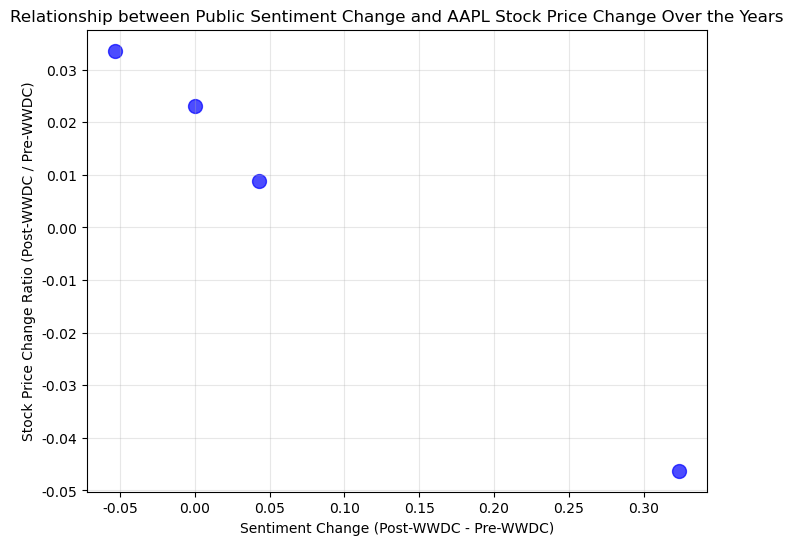

In [30]:
# Merge the extracted data
analysis_df = pd.DataFrame({
    'year': list(wwdc_stock_windows.keys()),
    'price_change': [wwdc_stock_windows[year]['price_change'] for year in wwdc_stock_windows.keys()],
    'sentiment_diff': [wwdc_sentiments[year]['sentiment_diff'] for year in wwdc_stock_windows.keys()]
}).set_index('year')

print("Data of sentiment change and stock price change:")
print(analysis_df)

# Draw scatter plot with English labels
plt.figure(figsize=(8,6))
plt.scatter(analysis_df['sentiment_diff'], analysis_df['price_change'], s=100, color='blue', alpha=0.7)
plt.xlabel('Sentiment Change (Post-WWDC - Pre-WWDC)')
plt.ylabel('Stock Price Change Ratio (Post-WWDC / Pre-WWDC)')
plt.title('Relationship between Public Sentiment Change and AAPL Stock Price Change Over the Years')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# 使用简单的线性回归模型，预测股价变化与舆情变化间的关系
X = analysis_df[['sentiment_diff']].values
y = analysis_df['price_change'].values

model = LinearRegression()
model.fit(X, y)

print("回归模型系数：", model.coef_[0])
print("回归模型截距：", model.intercept_)
print("模型拟合得分 (R^2)：", model.score(X, y))

回归模型系数： -0.2108778934030383
回归模型截距： 0.021269221795800007
模型拟合得分 (R^2)： 0.9956245322754543


In [9]:
# 假设我们预测 2025 年 WWDC 时的舆情数据（这里同样使用模拟数据）
pred_2025_pre_sentiment = np.random.uniform(-0.2, 0.2)
pred_2025_post_sentiment = np.random.uniform(-0.2, 0.2)
pred_2025_sentiment_diff = pred_2025_post_sentiment - pred_2025_pre_sentiment

print(f"2025 年预测：WWDC 前舆情 {pred_2025_pre_sentiment:.3f}，WWDC 后舆情 {pred_2025_post_sentiment:.3f} ，舆情变化 {pred_2025_sentiment_diff:.3f}")

predicted_price_change = model.predict(np.array([[pred_2025_sentiment_diff]]))[0]
print(f"预测 2025 年 WWDC 后 AAPL 股价变化比例：{predicted_price_change:.2%}")

# 如果需要预测绝对价格，则需结合当前价格或前期均价
# 例如假设设定 WWDC 前7天均价为 current_pre_price，则后均价预测为：
# predicted_post_price = current_pre_price * (1 + predicted_price_change)

2025 年预测：WWDC 前舆情 -0.192，WWDC 后舆情 0.188 ，舆情变化 0.380
预测 2025 年 WWDC 后 AAPL 股价变化比例：-5.88%


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

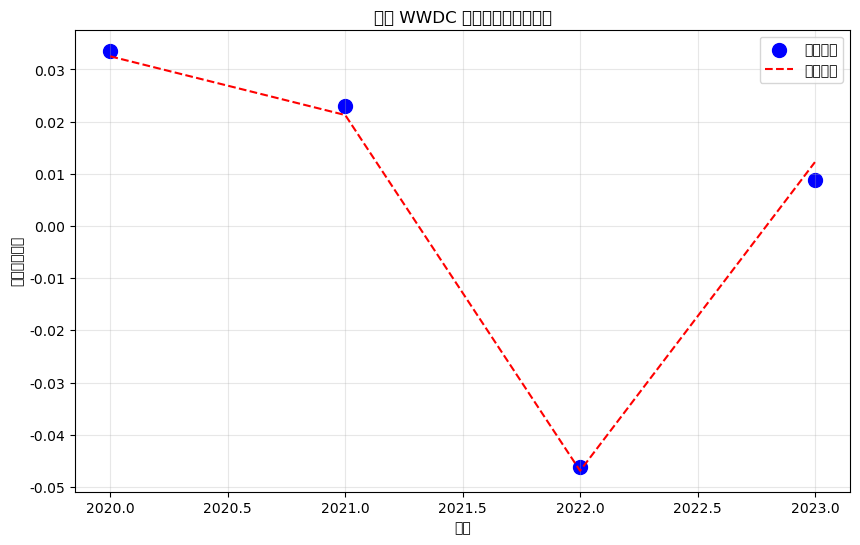

总结：
1. 通过历年数据，初步建立了舆情变化与股价变化之间的线性关系模型。
2. 依据模拟的2025年 WWDC 前后舆情数据，预测了 AAPL 在 WWDC 后的股价变化趋势。
3. 该模型基于模拟数据，实际应用时需要使用真实的社交媒体情绪数据，并对 AAPL 的数据来源加以验证。


In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(analysis_df.index, analysis_df['price_change'], color='blue', s=100, label='Historical Data')
plt.plot(analysis_df.index, model.predict(analysis_df[['sentiment_diff']]), 'r--', label='Regression Fit')
plt.xlabel('Year')
plt.ylabel('Stock Price Change Ratio')
plt.title('Annual WWDC Stock Price Change and Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("总结：")
print("1. 通过历年数据，初步建立了舆情变化与股价变化之间的线性关系模型。")
print("2. 依据模拟的2025年 WWDC 前后舆情数据，预测了 AAPL 在 WWDC 后的股价变化趋势。")
print("3. 该模型基于模拟数据，实际应用时需要使用真实的社交媒体情绪数据，并对 AAPL 的数据来源加以验证。")